This notebook demonstrates how to train an LSD model on a dataset with a prior pseudotime. It covers data preprocessing, LSD model initialization, random-walk generation, and model training.


In [38]:
import os
import sys
sys.path.insert(0, os.path.abspath('../..'))
#import statements
import scanpy as sc
import scvelo as scv
from codes.lsd_train import LSD
from codes.config import LSDConfig
from codes.utils import plot_random_walks
import pyro
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# read the dataset
adata  = scv.datasets.bonemarrow()
#store the raw counts
adata.layers["raw"] = adata.X.copy()
#preprocess
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
#select hvgs
sc.pp.filter_genes_dispersion(adata, n_top_genes= 2000)
sc.pp.filter_cells(adata, min_counts= 50)
# normalize raw counts to target sum 1e4
adata.X = adata.layers["raw"].copy()
sc.pp.normalize_total(adata, target_sum= 1e4)
sc.pp.log1p(adata)
#get the library size
adata.obs["librarysize"] = adata.layers['raw'].sum(axis = 1)
#knn graph
sc.pp.pca(adata)
sc.pp.neighbors(adata)

/projects/apour/NDE311/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


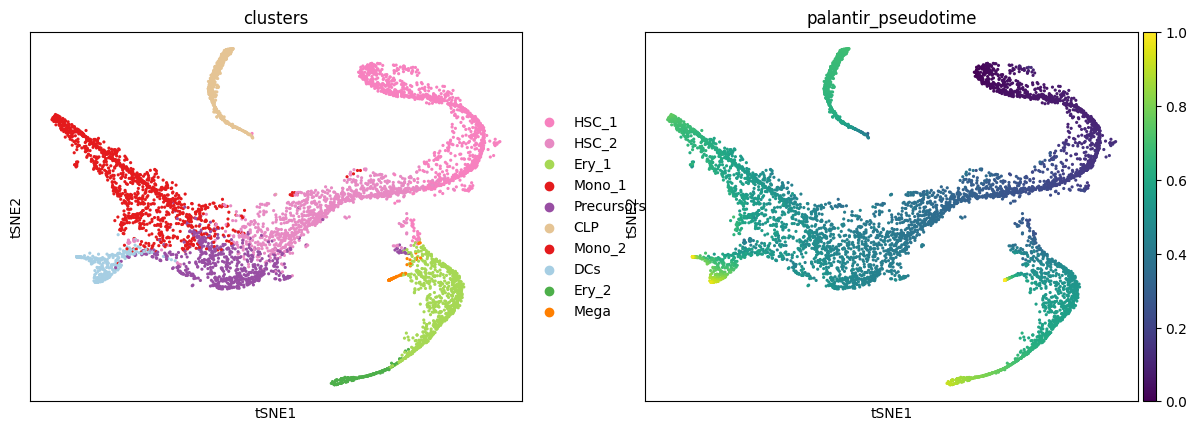

In [3]:
#inspect the dataset
sc.pl.tsne(adata, color = ["clusters", "palantir_pseudotime"])

In [4]:
#confgiure and initialze LSD model
cfg = LSDConfig()
#set the hyperparameters. here we set lr, number of random walks and length of random walks
cfg.walks.num_walks = 1024
cfg.walks.path_len = 20
cfg.optimizer.adam.lr = 2e-3
lsd = LSD(adata, cfg, raw_count_key= "raw", lib_size_key= "librarysize", device = device)

In [5]:
# set up phylogeny in case you have prior knowledge about cell hierarchy
# this step is not mandatory for model training
# e.g. in bone marrow case we have something like this
phylogeny = {
    "HSC_1":             ["HSC_2", "Ery_1", "Mega"], 
    "Ery_1":       ["Ery_2"],         
    "HSC_2": ["Precursors"],                 
    "Precursors":   ["Mono_1", "Mono_2", "DCs"],                         
    "Ery_2": [],                     # Terminal states
    "DCs":       [],
    "Mono_1": [],
    "Mono_2": [],
    "CLP": []                             
}

# this information refines the random walk generation process
# feed the phylogeny to LSD model
lsd.set_phylogeny(phylogeny, cluster_key="clusters")

[LSD] Removing 12 cells with no transitions:
[LSD] Prior transition matrix set from phylogeny and pseudotime.


/projects/apour/NDE311/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


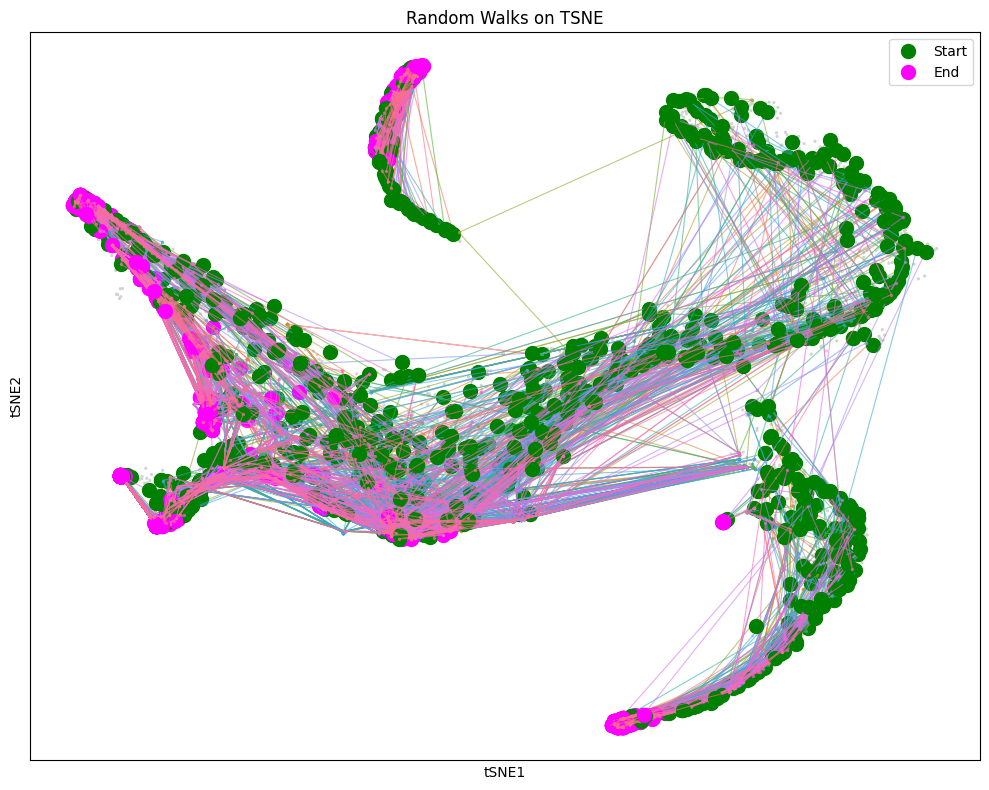

In [ ]:
#generate and visualize random walks
#first step, derive a cell by cell transition matrix from pseudotime
lsd.set_prior_transition(prior_time_key="palantir_pseudotime")
#in case you have a precomputed transition matrix you want to use (e.g. adata.obsp["transition_matrix"]) simply use the prompt below
# lsd.set_prior_transition(prior_transition=adata.obsp["transition_matrix"])
#second step, generate the random walks
lsd.prepare_walks()
#third step, visualize random walks for sanity check
plot_random_walks(lsd.adata, lsd.walks, "X_tsne")

Training Epochs: 100%|██████████| 120/120 [07:37<00:00,  3.81s/it, -ELBO=1.1494, Potential Metric=0.2821, Entropy Metric=0.0333]


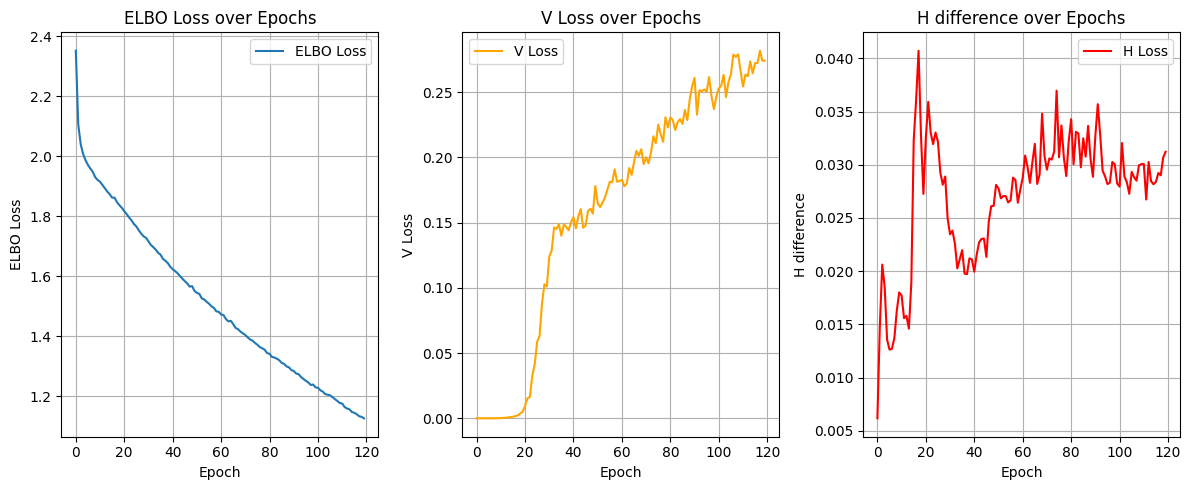

In [7]:
#train LSD model
pyro.set_rng_seed(42)
num_epochs = 120
#model save dir
save_dir = "../../Models/Tutorial_model"
os.makedirs(save_dir, exist_ok=True)
# Train the model
lsd.train(
    num_epochs=num_epochs, 
    save_dir=save_dir,
    save_interval=50,           # Save every 50 epochs
    random_state=42             # Random seed
)


/projects/apour/NDE311/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


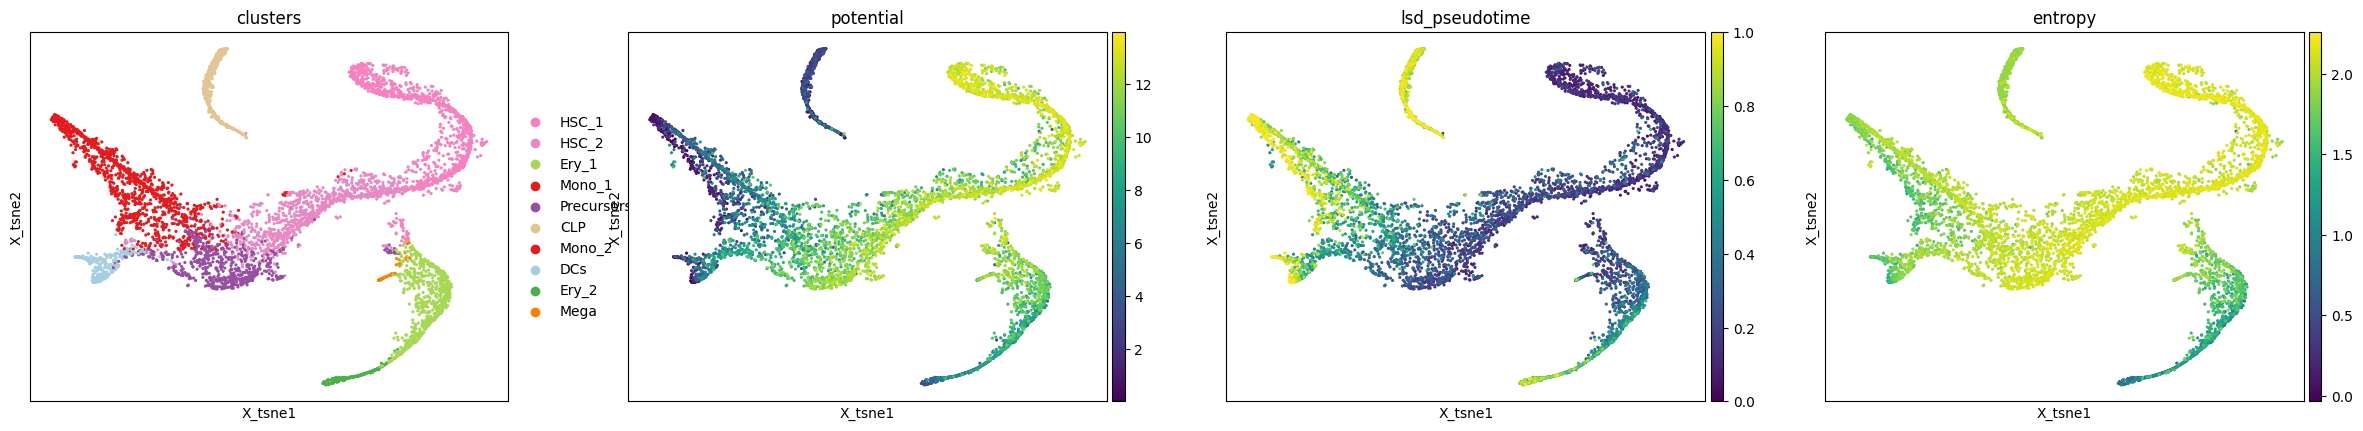

/projects/apour/NDE311/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


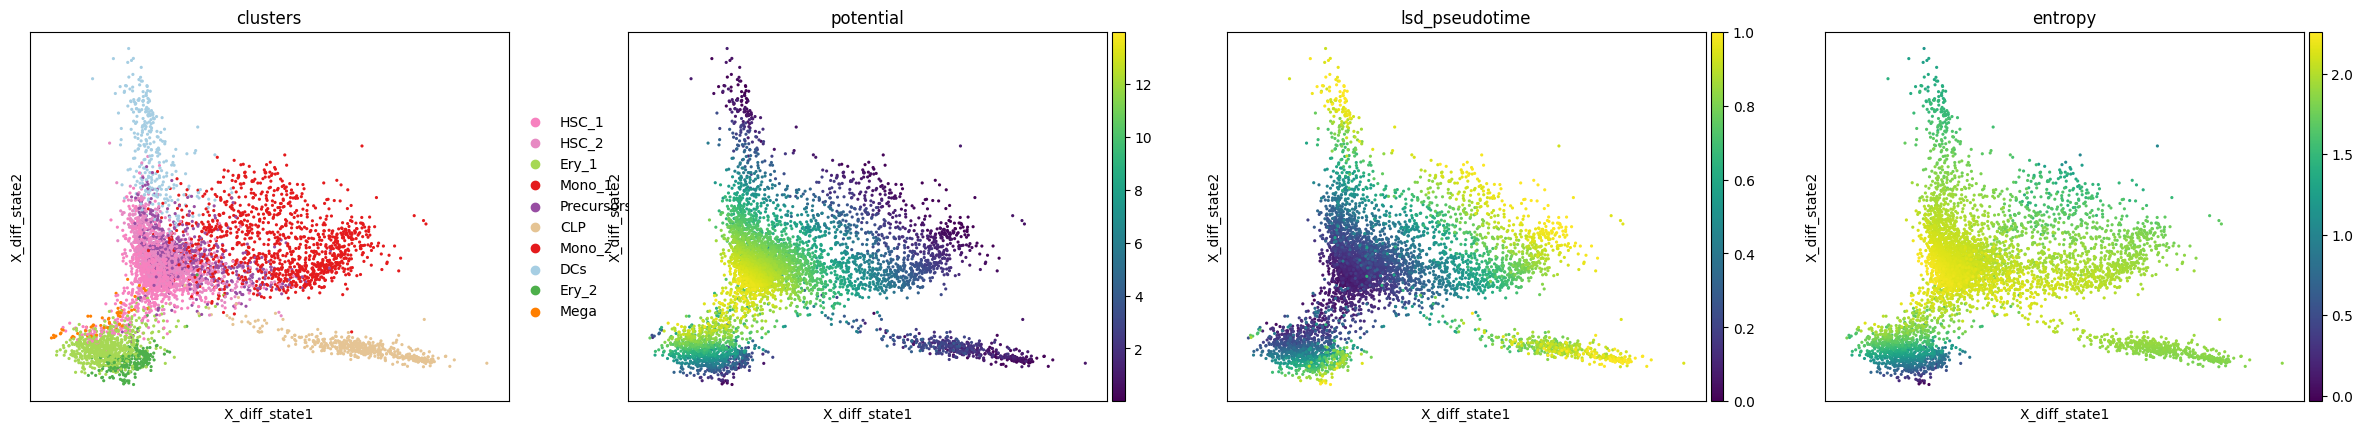

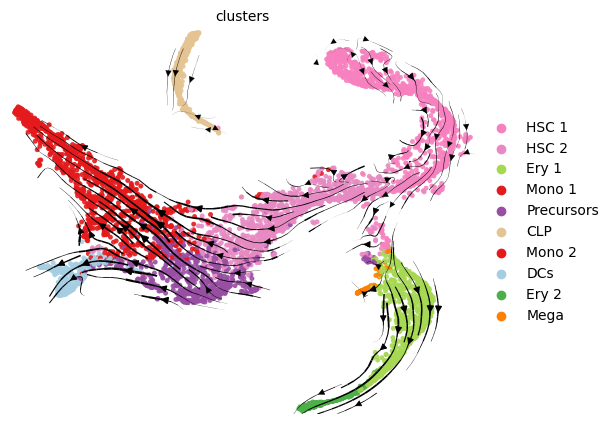

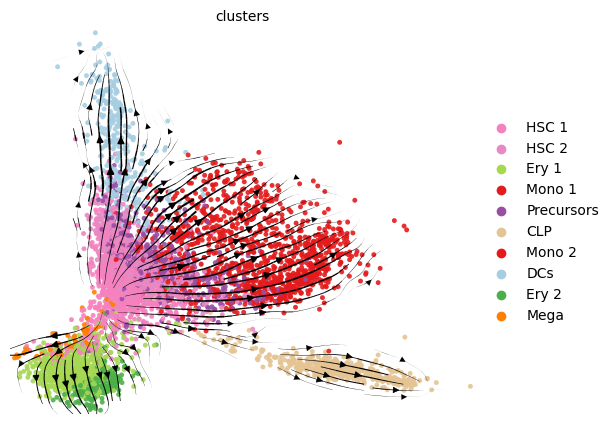

<Axes: title={'center': 'clusters'}>

In [8]:
#get the lsd outputs
final_adata = lsd.get_adata()
#plot the outputs
colors = ["clusters","potential", "lsd_pseudotime", "entropy"]
sc.pl.embedding(final_adata, color = colors, basis = "X_tsne")
#visualize differentiation state
sc.pl.embedding(final_adata, color = colors, basis = "X_diff_state")
#inspect flow fields
lsd.stream_lines(embedding= "X_tsne", size = 50)
lsd.stream_lines(embedding= "X_diff_state", size = 50)

In [14]:
#using LSD to predict cell fates
dyn_adata = lsd.get_cell_fates(final_adata, time_range= 10, cluster_key = "clusters")

/projects/apour/NDE311/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


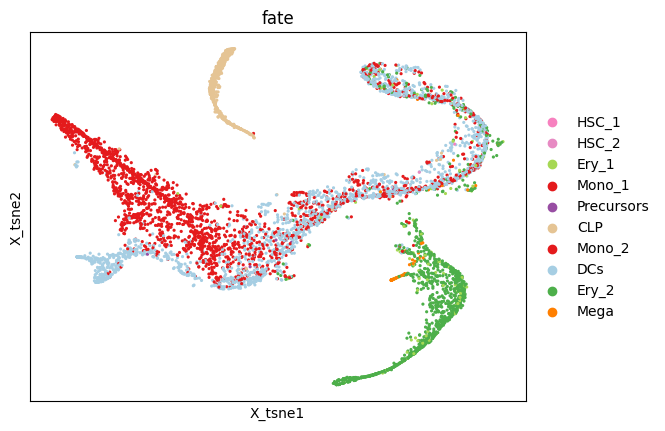

/projects/apour/NDE311/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


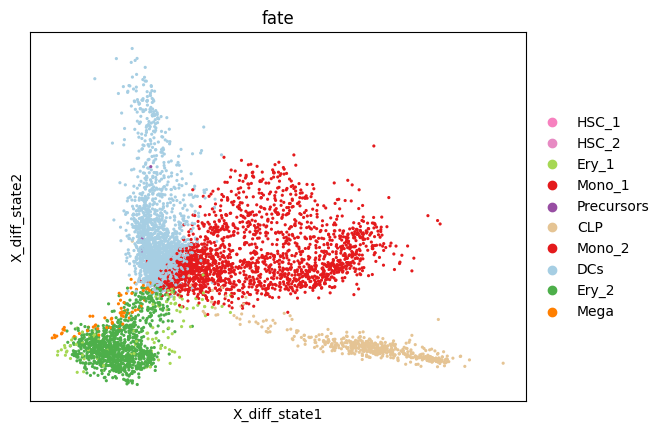

In [10]:
#visualize cell fates
dyn_adata.uns["fate_colors"] = dyn_adata.uns["clusters_colors"]
sc.pl.embedding(dyn_adata, color = "fate", basis = "X_tsne")
sc.pl.embedding(dyn_adata, color = "fate", basis = "X_diff_state")


In [ ]:
#gene perturbation
#for gene perturbation you need three to set three parameters:
# 1- name of gene, 2- number of perturbation iterations 3-level of perturbation (e.g. for KO level = 0)
#prepare adata
x = torch.from_numpy(dyn_adata.X.toarray()) 
idx = np.where(dyn_adata.obs['clusters'].isin(["HSC_1", "HSC_2"]))[0]
IC = x[idx].to(device)
# we KO GATA2 only HSC cells
# see https://www.nature.com/articles/s41587-019-0068-4 for role of GATA2 as a driver of erythroid lineage
#perturbation analysis returns the predicted cell fate in perturbed and unperturbed scenarios for provided cells
perturbed_fates, unperturbed_fates = lsd.perturb(
    adata=dyn_adata,
    x=IC,
    gene_name="GATA2",
    pertubation_level= 0,
    max_perturbations= 10,
    cluster_key="clusters",
    batch_size= 4096
    )

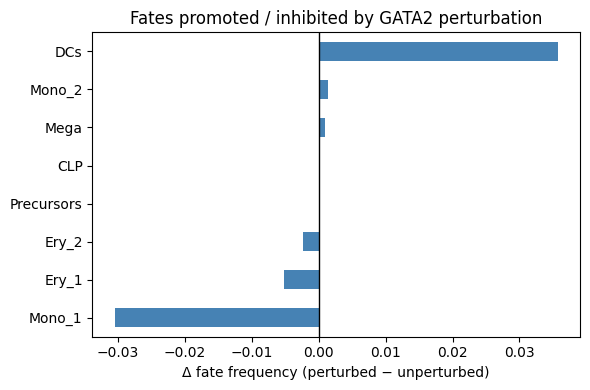

In [ ]:
#here we show the predicted change in the frequency of each fate after GATA2 KO
df = pd.DataFrame({
    "cell_id": dyn_adata.obs_names[idx],
    "unperturbed_fate": np.asarray(unperturbed_fates, dtype=object),
    "perturbed_fate": np.asarray(perturbed_fates, dtype=object),
    "lsd_pseudotime": dyn_adata.obs["lsd_pseudotime"].iloc[idx].values,
    "cluster": dyn_adata.obs["clusters"].iloc[idx].astype(str).values,
})

# fate-change indicator
df["changed"] = df["unperturbed_fate"] != df["perturbed_fate"]
# Counts before and after perturbation
fate_counts = (
    pd.concat([
        df["unperturbed_fate"].value_counts().rename("unperturbed"),
        df["perturbed_fate"].value_counts().rename("perturbed"),
    ], axis=1)
    .fillna(0)
)

# Normalize to fractions
fate_freq = fate_counts.div(fate_counts.sum(axis=0), axis=1)

# Net effect of perturbation
fate_freq["delta"] = fate_freq["perturbed"] - fate_freq["unperturbed"]

fate_freq.sort_values("delta", ascending=False)
promoted = fate_freq[fate_freq["delta"] > 0].sort_values("delta", ascending=False)
inhibited = fate_freq[fate_freq["delta"] < 0].sort_values("delta")

promoted[["delta"]], inhibited[["delta"]]
plt.figure(figsize=(6, 4))
fate_freq["delta"].sort_values().plot.barh(color="steelblue")
plt.axvline(0, color="k", lw=1)
plt.xlabel("Δ fate frequency (perturbed − unperturbed)")
plt.title("Fates promoted / inhibited by GATA2 perturbation")
plt.tight_layout()
plt.show()


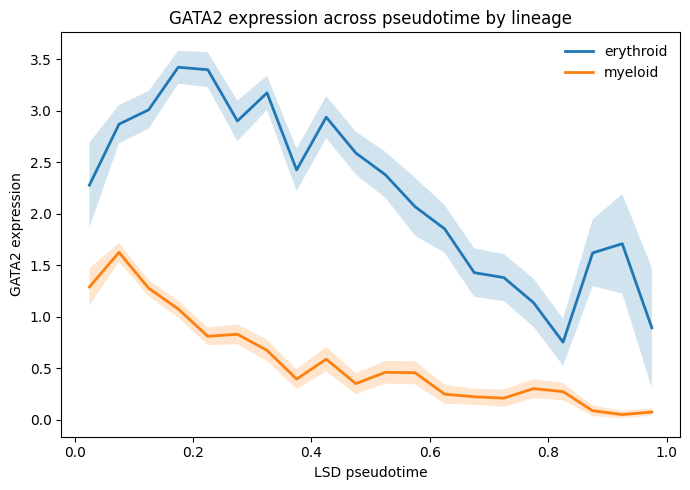

In [40]:
#Expression dynamics of GATA2
# --- Settings ---
gene = "GATA2"
pt_key = "lsd_pseudotime"
cluster_key = "fate"   # change if your cluster labels live in a different obs column
n_bins = 20

# Map fine clusters -> coarse lineage
lineage_map = {
    **{k: "erythroid" for k in ["Ery_1", "Ery_2", "Mega"]},
    **{k: "myeloid"   for k in ["Precursors", "Mono_1", "Mono_2", "DCs"]},
    **{k: "lymphoid"  for k in ["CLP"]},
}
keep = list(lineage_map.keys())

# --- Subset + pull expression ---
adata = dyn_adata[dyn_adata.obs[cluster_key].isin(keep)].copy()
X = adata[:, gene].X
expr = X.toarray().ravel() if sp.issparse(X) else np.asarray(X).ravel()

pt = adata.obs[pt_key].to_numpy(dtype=float)
lineage = adata.obs[cluster_key].map(lineage_map).to_numpy(dtype=object)

m = ~np.isnan(pt)
expr, pt, lineage = expr[m], pt[m], lineage[m]

# --- Bin pseudotime and aggregate mean +/- SE per lineage ---
edges = np.linspace(pt.min(), pt.max(), n_bins + 1)
bin_id = np.clip(np.digitize(pt, edges) - 1, 0, n_bins - 1)
centers = 0.5 * (edges[:-1] + edges[1:])

df = pd.DataFrame({"lineage": lineage, "bin": bin_id, "expr": expr})
agg = (df.groupby(["lineage", "bin"])
         .agg(mean=("expr", "mean"),
              se=("expr", lambda x: x.std(ddof=1)/np.sqrt(len(x)) if len(x) > 1 else 0.0))
         .reset_index())
agg["pt"] = centers[agg["bin"].to_numpy()]

# --- Plot ---
plt.figure(figsize=(7, 5))
for lin in ["erythroid", "myeloid"]:
    sub = agg[agg.lineage == lin].sort_values("pt")
    plt.plot(sub["pt"], sub["mean"], lw=2, label=lin)
    plt.fill_between(sub["pt"], sub["mean"] - sub["se"], sub["mean"] + sub["se"], alpha=0.2)

plt.xlabel("LSD pseudotime")
plt.ylabel("GATA2 expression")
plt.title("GATA2 expression across pseudotime by lineage")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
